# Recluster `maintain heading` and `alignment` bursts on reduced motor features ($T_\mathrm{react}, \Delta m$ only) 

In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import QuantileTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score

In [2]:
fish_ages = [4,6,8]

sensory_feature_names = ["initial_L_0","initial_L_1","initial_L_2","initial_m_0","initial_m_1","initial_m_2","cosine_avoidance_0","cosine_avoidance_1","cosine_avoidance_2", "distance_to_wall"]
motor_feature_names = ["T_burst","cum_delta_theta","delta_L_0","delta_L_1","delta_L_2","delta_m_0","delta_m_1","delta_m_2","reaction_time_0","reaction_time_1","reaction_time_2", "delta_v"]


# laod optimal gmms
results_path = '../../Results/optimal_sensory_motor_clusters.pkl'

with open(results_path, 'rb') as f:
    optimal_gmm_results = pickle.load(f)
    optimal_gmms_sensory = optimal_gmm_results['optimal_gmms_sensory']
    optimal_gmms_motor = optimal_gmm_results['optimal_gmms_motor']
    feature_dfs_with_labels = optimal_gmm_results['feature_dfs_with_labels']

agewise_motor_cluster_names = [
    ['diffusion', 'cohesion', 'maintain heading', 'alignment'],
    ['diffusion', 'alignment', 'cohesion', 'maintain heading'],
    ['diffusion', 'cohesion', 'maintain heading', 'alignment']
]
agewise_sensory_cluster_names= [
    ['alone', 'triad', 'pair'],
    ['school\n(back)', 'triad\n(front)', 'school\n(front)', 'triad\n(back)', 'pair', 'alone'],
    ['school\n(middle)', 'school\n(back)', 'school\n(front)', 'pair']

]

# Fit GMM and visualize results

In [38]:
n_init = 10000
random_state = 0 
n_subcomponents = 3


features_to_use = ["reaction_time_0", "reaction_time_1", "reaction_time_2", "delta_m_0", "delta_m_1", "delta_m_2"]
i = 2 # 8wpf
age = fish_ages[i]
feature_df = feature_dfs_with_labels[f'{age}wpf']
mh_cluster_idx = np.flatnonzero(np.array(agewise_motor_cluster_names[i])=='maintain heading')[0]
alignment_cluster_idx = np.flatnonzero(np.array(agewise_motor_cluster_names[i])=='alignment')[0]
feature_df_reduced = feature_df.loc[np.logical_or(feature_df['motor_cluster']==mh_cluster_idx,feature_df['motor_cluster']==alignment_cluster_idx), features_to_use].copy()

gmm = GaussianMixture(
    n_components=n_subcomponents,
    covariance_type='full',
    random_state=random_state,
    n_init=n_init,
    init_params='kmeans'
)

scaler = QuantileTransformer(output_distribution='normal')
scaled_features = scaler.fit_transform(feature_df_reduced)
gmm.fit(scaled_features)
labels = gmm.predict(scaled_features)


In [39]:
feature_df_reduced["motor_sub_labels"] = labels
subcluster_names = ['Align w/\nnearest', 'Realign', 'Misalign w/\nnearest' ]

colors_subcluster = np.array([       [0.7372549 , 0.74117647, 0.13333333, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [0.08627451, 0.20392157, 1.  ,1]      ])



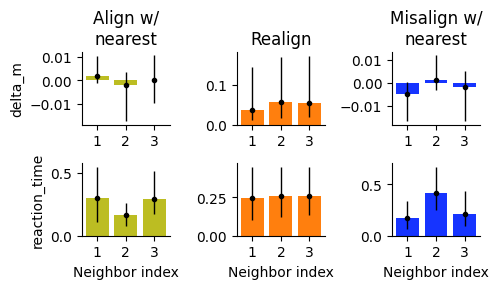

In [40]:
fig, ax =plt.subplots(2,3, figsize=(5,3))
n_clusters = len(subcluster_names)

# calculate means
means = feature_df_reduced.groupby('motor_sub_labels').quantile(0.5)
lower_bound = feature_df_reduced.groupby('motor_sub_labels').quantile(0.25)
upper_bound = feature_df_reduced.groupby('motor_sub_labels').quantile(0.75)

features_to_plot = ['delta_m', "reaction_time"]

for i, feature in enumerate(features_to_plot):
    for j in range(n_clusters):
        col_names = [f'{feature}_{r}' for r in range(3)]
        ax[i,j].bar(range(3), means.loc[j, col_names], color=colors_subcluster[j])
        ax[i,j].errorbar(range(3), means.loc[j, col_names], yerr=[means.loc[j, col_names]-lower_bound.loc[j, col_names], upper_bound.loc[j, col_names]-means.loc[j, col_names]], color='k', marker='o',linestyle='None', alpha=1, markersize=3, elinewidth=1)
        if i == 0:
            ax[i,j].set_title(subcluster_names[j])
        else:
            ax[i,j].set_xlabel("Neighbor index")

        ax[i,j].set_xticks(range(3), range(1,4))

        if j==0:
            ax[i,j].set_ylabel(feature)    
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)

fig.tight_layout()